# Домашнее задание к семинарам 08-09 (HW08-09)

Тема: PyTorch 101 b основы оптимизации обучения.
Часть S08: MLP b регуляризация (Dropout, BatchNorm, EarlyStopping).
Часть S09: learning rate диагностика, Adam vs SGD+momentum, weight decay.

---

## 1. Цель

Закрепить:

- базовые сущности PyTorch: `Tensor`, `Dataset/DataLoader`, `nn.Module`, loss, optimizer, цикл обучения;
- корректный режим обучения/валидации: `model.train()` / `model.eval()` и `torch.no_grad()`;
- практическое управление переобучением: **Dropout**, **BatchNorm**, **EarlyStopping**;
- базовые рычаги обучения: learning rate (плохой/хороший), сравнение Adam и SGD+momentum, использование weight decay;
- аккуратное оформление результатов: один ноутбук, короткий отчёт, артефакты эксперимента.

---

## 2. Задание

### 2.1. Структура для HW08-09 (обязательно)

1. В корне репозитория должна быть папка `homeworks/` (создать, если её ещё нет).
2. Внутри `homeworks/` создать папку `HW08-09/`.
3. В папке `homeworks/HW08-09/` создать:

- основной ноутбук: `HW08-09.ipynb`
- отчёт: `report.md`
- папку для артефактов: `artifacts/`
  - рекомендуется внутри `artifacts/` завести подпапку `figures/` для графиков

> Имена папок и файлов должны быть строго такими, как указано (регистр важен).

---

### 2.2. Учебные датасеты (выбрать один из трёх)

Выберите **один** датасет из списка (все доступны через `torchvision`):

- Вариант B: EMNIST(split="balanced")

Требования к данным:

- используйте стандартный train/test из torchvision;
- сделайте **валидацию**: отделите `val` от `train` (например, 80/20), разбиение должно быть воспроизводимым (фиксированный seed);
- путь к данным в ноутбуке – стандартный (через torchvision), без абсолютных путей к домашним каталогам.

---

### 2.3. Содержание ноутбука `HW08-09.ipynb` (обязательно)

В ноутбуке `homeworks/HW08-09/HW08-09.ipynb` реализуйте и покажите следующие блоки.

#### 2.3.1. Импорты, seed и устройство

1) Импортировать библиотеки: `torch`, `torchvision`, `numpy`, `matplotlib` (и всё, что нужно по делу).  
2) Зафиксировать seed (минимум `torch.manual_seed`, желательно также `numpy`).  
3) Определить устройство (`cuda` при наличии, иначе `cpu`) и убедиться, что и модель, и батчи переводятся на один device.

#### 2.3.2. Данные и DataLoader

1) Загрузить выбранный датасет через `torchvision.datasets.*`.  
2) Определить `transform` (минимум `ToTensor()`, нормализация – по желанию).  
3) Сделать разбиение `train/val` из train-части с фиксированным seed.  
4) Создать `DataLoader` для train/val/test.  
5) Показать sanity-check: размеры батча, shapes (`x.shape`, `y.shape`), диапазоны значений.

#### 2.3.3. Модель MLP и цикл обучения

1) Реализовать MLP как `nn.Module` (Flatten, Linear, …, logits).  
2) Выбрать:

    - loss: `CrossEntropyLoss`;
    - optimizer: `Adam` (по умолчанию для базовых экспериментов);
    - метрика: accuracy (достаточно).  

3) Реализовать функции (или эквивалент):

    - `train_one_epoch(...)`
    - `evaluate(...)` (с `model.eval()` и `torch.no_grad()`)  

4) Логировать историю обучения: train/val loss и train/val accuracy по эпохам.

---

In [2]:
# 1) Импорты
import random
import numpy as np
import os, json, csv

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import datasets, transforms

import time
import math
import matplotlib.pyplot as plt

# 2) Повторяемость
SEED = 42
random.seed(SEED)          # случайности Python
np.random.seed(SEED)       # случайности NumPy
torch.manual_seed(SEED)    # случайности PyTorch (CPU)
torch.cuda.manual_seed_all(SEED)  # случайности PyTorch (GPU)

# (для полной воспроизводимости на GPU)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# 3) Устройство: GPU если доступен, иначе CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('device:', device)
print('torch:', torch.__version__)
print("torchvision:", torchvision.__version__)

device: cpu
torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


In [3]:
#2.3.2 Данные и DataLoader (KMNIST)

DATA_DIR = "./data" 

#2) Transform (ToTensor + нормализация)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),         
])

#1) Загрузить выбранный датасет через torchvision.datasets

# Важно: для EMNIST нужно указать split="balanced"
train_full = datasets.EMNIST(
    root=DATA_DIR, split="balanced", train=True, download=True, transform=transform
)
test_ds = datasets.EMNIST(
    root=DATA_DIR, split="balanced", train=False, download=True, transform=transform
)

print("Train full size:", len(train_full))
print("Test size:", len(test_ds))
print("Num classes:", len(train_full.classes))  # пригодится для num_classes в MLP

#3) Сделаем разбиение train/val из train-части с фиксированным seed

val_ratio = 0.2
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(SEED)  
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

print("Train size:", len(train_ds))
print("Val size:", len(val_ds))

# 4) Создать DataLoader для train/val/test

BATCH_SIZE = 256 if device.type == "cuda" else 64
NUM_WORKERS = 0 if os.name == "nt" else 2

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

#5) Sanity-check (батч, shapes, диапазоны)

x, y = next(iter(train_loader))

print("Batch size:", x.shape[0])
print("x.shape:", x.shape, "| y.shape:", y.shape)
print("x dtype:", x.dtype, "| y dtype:", y.dtype)
print("x min/max:", x.min().item(), x.max().item())
print("y min/max:", y.min().item(), y.max().item())


Train full size: 112800
Test size: 18800
Num classes: 47
Train size: 90240
Val size: 22560
Batch size: 64
x.shape: torch.Size([64, 1, 28, 28]) | y.shape: torch.Size([64])
x dtype: torch.float32 | y dtype: torch.int64
x min/max: -1.0 1.0
y min/max: 0 46


In [4]:
#2.3.3 Модель MLP и цикл обучения

num_classes = len(train_full.classes)  # EMNIST balanced

#1) Реализовать MLP как nn.Module (Flatten, Linear, …, logits)

class MLP(nn.Module):
    def __init__(self, hidden_sizes=(512, 256), num_classes=num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),                         # (B,1,28,28) -> (B,784)
            nn.Linear(28 * 28, hidden_sizes[0]),
            nn.ReLU(),
            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(),
            nn.Linear(hidden_sizes[1], num_classes)  # logits
        )

    def forward(self, x):
        return self.net(x)

model = MLP().to(device)
print(model)

#2) Выбрать: Loss, optimizer, accuracy

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def accuracy_from_logits(logits, y_true):
    preds = logits.argmax(dim=1)
    return (preds == y_true).float().mean().item()

#3) Реализовать функции (или эквивалент)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, total_acc, n_batches = 0.0, 0.0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc  += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_acc, n_batches = 0.0, 0.0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc  += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

#4) Логировать историю обучения: train/val loss и train/val accuracy по эпохам

num_epochs = 10

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc     = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch:02d}/{num_epochs} | "
        f"train loss={train_loss:.4f}, acc={train_acc:.4f} | "
        f"val loss={val_loss:.4f}, acc={val_acc:.4f}"
    )

MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=47, bias=True)
  )
)
Epoch 01/10 | train loss=1.0390, acc=0.6876 | val loss=0.7191, acc=0.7671
Epoch 02/10 | train loss=0.6053, acc=0.7991 | val loss=0.5963, acc=0.8075
Epoch 03/10 | train loss=0.5142, acc=0.8257 | val loss=0.5338, acc=0.8232
Epoch 04/10 | train loss=0.4663, acc=0.8381 | val loss=0.5359, acc=0.8183
Epoch 05/10 | train loss=0.4278, acc=0.8482 | val loss=0.5173, acc=0.8296
Epoch 06/10 | train loss=0.4001, acc=0.8564 | val loss=0.5156, acc=0.8311
Epoch 07/10 | train loss=0.3789, acc=0.8610 | val loss=0.5214, acc=0.8310
Epoch 08/10 | train loss=0.3549, acc=0.8688 | val loss=0.5154, acc=0.8364
Epoch 09/10 | train loss=0.3368, acc=0.8727 | val loss=0.5358, acc=0.8363
Epoch 10/10 | train loss=0.3200, acc=0.8780

## 3. Эксперименты

В домашней работе есть две части: (A) регуляризация (S08) и (B) оптимизация (S09).
Все результаты прогонов фиксируются в `artifacts/runs.csv` (см. раздел 4).

### 3.1. Часть A (S08): регуляризация и переобучение (обязательно)
Задача: показать эффект Dropout/BatchNorm и ранней остановки.

Провести 4 эксперимента (E1-E4). Эксперимент = фиксированный конфиг модели/обучения + обучение + оценка на val.

- **E1 (base)**: MLP побольше (например, 2-3 скрытых слоя), без Dropout и без BatchNorm.
- **E2 (Dropout)**: как E1, но добавить Dropout (например, p=0.2-0.5).
- **E3 (BatchNorm)**: как E1, но добавить BatchNorm (между Linear и активацией).
- **E4 (EarlyStopping)**: выбрать **лучший** из (E2/E3) по `val_accuracy` и обучить его с EarlyStopping (patience 3-5).
  - именно E4 считается "лучшей моделью домашки" и из него сохраняется `best_model.pt`.

Важно:

- сравнение должно быть корректным: одинаковые split/train settings (где уместно), одинаковое число эпох (кроме early stopping);
- test-часть используйте **один раз**: только для финальной оценки лучшей модели после выбора по val.

In [5]:
# Подготовка: три модели 

# E1 base: 3 скрытых слоя, без Dropout/BN

hidden_sizes_big = (512, 256, 128)   # "MLP побольше"
lr = 1e-3
num_epochs_exp = 10                  # одинаково для E1-E3

class MLP_Base(nn.Module):
    def __init__(self, hidden_sizes=hidden_sizes_big, num_classes=num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, hidden_sizes[0]), nn.ReLU(),
            nn.Linear(hidden_sizes[0], hidden_sizes[1]), nn.ReLU(),
            nn.Linear(hidden_sizes[1], hidden_sizes[2]), nn.ReLU(),
            nn.Linear(hidden_sizes[2], num_classes)  # logits
        )

    def forward(self, x):
        return self.net(x)

# E2 Dropout: как E1, но Dropout p=0.3

p_dropout = 0.3

class MLP_Dropout(nn.Module):
    def __init__(self, hidden_sizes=hidden_sizes_big, p=p_dropout, num_classes=num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, hidden_sizes[0]), nn.ReLU(), nn.Dropout(p),
            nn.Linear(hidden_sizes[0], hidden_sizes[1]), nn.ReLU(), nn.Dropout(p),
            nn.Linear(hidden_sizes[1], hidden_sizes[2]), nn.ReLU(), nn.Dropout(p),
            nn.Linear(hidden_sizes[2], num_classes)  # logits
        )

    def forward(self, x):
        return self.net(x)

# E3 BatchNorm: как E1, но BN между Linear и ReLU

class MLP_BN(nn.Module):
    def __init__(self, hidden_sizes=hidden_sizes_big, num_classes=num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),

            nn.Linear(28*28, hidden_sizes[0]),
            nn.BatchNorm1d(hidden_sizes[0]),
            nn.ReLU(),

            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.BatchNorm1d(hidden_sizes[1]),
            nn.ReLU(),

            nn.Linear(hidden_sizes[1], hidden_sizes[2]),
            nn.BatchNorm1d(hidden_sizes[2]),
            nn.ReLU(),

            nn.Linear(hidden_sizes[2], num_classes)  # logits
        )

    def forward(self, x):
        return self.net(x)


In [6]:
# E1: обучаем base 

torch.manual_seed(SEED)

model_E1 = MLP_Base().to(device)
optimizer_E1 = torch.optim.Adam(model_E1.parameters(), lr=lr)

history_E1 = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, num_epochs_exp + 1):
    train_loss, train_acc = train_one_epoch(model_E1, train_loader, criterion, optimizer_E1, device)
    val_loss, val_acc     = evaluate(model_E1, val_loader, criterion, device)

    history_E1["train_loss"].append(train_loss)
    history_E1["train_acc"].append(train_acc)
    history_E1["val_loss"].append(val_loss)
    history_E1["val_acc"].append(val_acc)

    print(f"E1 | epoch {epoch:02d}/{num_epochs_exp} | tr acc={train_acc:.4f} | va acc={val_acc:.4f}")

best_val_acc_E1 = max(history_E1["val_acc"])
print("E1 best val acc:", best_val_acc_E1)

E1 | epoch 01/10 | tr acc=0.6701 | va acc=0.7732
E1 | epoch 02/10 | tr acc=0.7948 | va acc=0.7938
E1 | epoch 03/10 | tr acc=0.8201 | va acc=0.8156
E1 | epoch 04/10 | tr acc=0.8368 | va acc=0.8268


E1 | epoch 05/10 | tr acc=0.8456 | va acc=0.8351
E1 | epoch 06/10 | tr acc=0.8541 | va acc=0.8286
E1 | epoch 07/10 | tr acc=0.8613 | va acc=0.8347
E1 | epoch 08/10 | tr acc=0.8660 | va acc=0.8360
E1 | epoch 09/10 | tr acc=0.8701 | va acc=0.8415
E1 | epoch 10/10 | tr acc=0.8741 | va acc=0.8383
E1 best val acc: 0.8415368271954674


In [7]:
# E2: обучаем Dropout

torch.manual_seed(SEED)

model_E2 = MLP_Dropout().to(device)
optimizer_E2 = torch.optim.Adam(model_E2.parameters(), lr=lr)

history_E2 = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, num_epochs_exp + 1):
    train_loss, train_acc = train_one_epoch(model_E2, train_loader, criterion, optimizer_E2, device)
    val_loss, val_acc     = evaluate(model_E2, val_loader, criterion, device)

    history_E2["train_loss"].append(train_loss)
    history_E2["train_acc"].append(train_acc)
    history_E2["val_loss"].append(val_loss)
    history_E2["val_acc"].append(val_acc)

    print(f"E2 | epoch {epoch:02d}/{num_epochs_exp} | tr acc={train_acc:.4f} | va acc={val_acc:.4f}")

best_val_acc_E2 = max(history_E2["val_acc"])
print("E2 best val acc:", best_val_acc_E2)


E2 | epoch 01/10 | tr acc=0.5406 | va acc=0.7393


E2 | epoch 02/10 | tr acc=0.6890 | va acc=0.7836
E2 | epoch 03/10 | tr acc=0.7199 | va acc=0.7974
E2 | epoch 04/10 | tr acc=0.7344 | va acc=0.8023
E2 | epoch 05/10 | tr acc=0.7472 | va acc=0.8135
E2 | epoch 06/10 | tr acc=0.7522 | va acc=0.8129
E2 | epoch 07/10 | tr acc=0.7579 | va acc=0.8164
E2 | epoch 08/10 | tr acc=0.7628 | va acc=0.8226
E2 | epoch 09/10 | tr acc=0.7659 | va acc=0.8223
E2 | epoch 10/10 | tr acc=0.7700 | va acc=0.8182
E2 best val acc: 0.8226363314447592


In [8]:
# E3: обучаем BatchNorm

torch.manual_seed(SEED)

model_E3 = MLP_BN().to(device)
optimizer_E3 = torch.optim.Adam(model_E3.parameters(), lr=lr)

history_E3 = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, num_epochs_exp + 1):
    train_loss, train_acc = train_one_epoch(model_E3, train_loader, criterion, optimizer_E3, device)
    val_loss, val_acc     = evaluate(model_E3, val_loader, criterion, device)

    history_E3["train_loss"].append(train_loss)
    history_E3["train_acc"].append(train_acc)
    history_E3["val_loss"].append(val_loss)
    history_E3["val_acc"].append(val_acc)

    print(f"E3 | epoch {epoch:02d}/{num_epochs_exp} | tr acc={train_acc:.4f} | va acc={val_acc:.4f}")

best_val_acc_E3 = max(history_E3["val_acc"])
print("E3 best val acc:", best_val_acc_E3)


E3 | epoch 01/10 | tr acc=0.7468 | va acc=0.8138


E3 | epoch 02/10 | tr acc=0.8250 | va acc=0.8344
E3 | epoch 03/10 | tr acc=0.8449 | va acc=0.8453
E3 | epoch 04/10 | tr acc=0.8582 | va acc=0.8518
E3 | epoch 05/10 | tr acc=0.8678 | va acc=0.8501
E3 | epoch 06/10 | tr acc=0.8750 | va acc=0.8498
E3 | epoch 07/10 | tr acc=0.8820 | va acc=0.8560
E3 | epoch 08/10 | tr acc=0.8878 | va acc=0.8536
E3 | epoch 09/10 | tr acc=0.8933 | va acc=0.8589
E3 | epoch 10/10 | tr acc=0.8967 | va acc=0.8567
E3 best val acc: 0.8589323654390935


In [9]:
# выбираем лучший из (E2/E3) по val_accuracy и обучаем с EarlyStopping

if best_val_acc_E2 >= best_val_acc_E3:
    best_kind = "dropout"
    print("Best between E2/E3: E2 (Dropout)")
else:
    best_kind = "bn"
    print("Best between E2/E3: E3 (BatchNorm)")

torch.manual_seed(SEED)

patience = 4
max_epochs_E4 = 30

# модель E4 = лучший вариант из E2/E3
if best_kind == "dropout":
    model_E4 = MLP_Dropout().to(device)
else:
    model_E4 = MLP_BN().to(device)

optimizer_E4 = torch.optim.Adam(model_E4.parameters(), lr=lr)

history_E4 = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

best_val = -1.0
bad_epochs = 0
best_state = None

for epoch in range(1, max_epochs_E4 + 1):
    train_loss, train_acc = train_one_epoch(model_E4, train_loader, criterion, optimizer_E4, device)
    val_loss, val_acc     = evaluate(model_E4, val_loader, criterion, device)

    history_E4["train_loss"].append(train_loss)
    history_E4["train_acc"].append(train_acc)
    history_E4["val_loss"].append(val_loss)
    history_E4["val_acc"].append(val_acc)

    print(f"E4 | epoch {epoch:02d}/{max_epochs_E4} | tr acc={train_acc:.4f} | va acc={val_acc:.4f}")

    if val_acc > best_val:
        best_val = val_acc
        bad_epochs = 0
        best_state = {k: v.detach().cpu().clone() for k, v in model_E4.state_dict().items()}
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print(f"E4 EarlyStopping: stop at epoch {epoch}")
            break

# восстановить лучшие веса
model_E4.load_state_dict(best_state)
print("E4 best val acc:", best_val)

Best between E2/E3: E3 (BatchNorm)
E4 | epoch 01/30 | tr acc=0.7468 | va acc=0.8138
E4 | epoch 02/30 | tr acc=0.8250 | va acc=0.8344
E4 | epoch 03/30 | tr acc=0.8449 | va acc=0.8453
E4 | epoch 04/30 | tr acc=0.8582 | va acc=0.8518
E4 | epoch 05/30 | tr acc=0.8678 | va acc=0.8501
E4 | epoch 06/30 | tr acc=0.8750 | va acc=0.8498
E4 | epoch 07/30 | tr acc=0.8820 | va acc=0.8560
E4 | epoch 08/30 | tr acc=0.8878 | va acc=0.8536
E4 | epoch 09/30 | tr acc=0.8933 | va acc=0.8589
E4 | epoch 10/30 | tr acc=0.8967 | va acc=0.8567
E4 | epoch 11/30 | tr acc=0.9029 | va acc=0.8542
E4 | epoch 12/30 | tr acc=0.9048 | va acc=0.8570
E4 | epoch 13/30 | tr acc=0.9102 | va acc=0.8576
E4 EarlyStopping: stop at epoch 13
E4 best val acc: 0.8589323654390935


In [10]:
# Тест
test_loss, test_acc = evaluate(model_E4, test_loader, criterion, device)
print("TEST | loss:", round(test_loss, 4), "| acc:", round(test_acc, 4))

TEST | loss: 0.4507 | acc: 0.8557


### 3.2. Часть B (S09): LR, оптимизаторы, weight decay (обязательно)

Задача: научиться диагностировать плохой LR по кривым, а также руками настроить SGD+momentum и weight decay.

Делаем 3 коротких эксперимента (O1-O3) на **фиксированной архитектуре** (той же, что в E4 по слоям/нейронам/Dropout/BN).

- **O1 (LR слишком большой)**: Adam, lr = "слишком большой" (например, 1e-1). Обучить 5-8 эпох и показать, что loss/метрики ведут себя плохо.
- **O2 (LR слишком маленький)**: Adam, lr = "слишком маленький" (например, 1e-5). Обучить 5-8 эпох и показать, что обучение почти не двигается.
- **O3 (SGD+momentum + weight decay)**: SGD с momentum (например, momentum=0.9) и **weight_decay > 0** (например, 1e-4).
  - lr взять разумный (например, как в E4 или подобрать в диапазоне 1e-2…1e-3).
  - обучить 10-15 эпох (или меньше, если на CPU долго).

Важно:

- O1 и O2 нужны **только для диагностики**, их модели не сохраняются как best.
- "Лучшая модель домашки" выбирается в части A (E4) по `val_accuracy` и затем проверяется на test.

---

In [11]:
# 1) Фиксируем архитектуру как в E4:
def make_model():
    if best_kind == "dropout":
        return MLP_Dropout().to(device)   
    elif best_kind == "bn":
        return MLP_BN().to(device)       
    else:
        raise ValueError("best_kind должен быть 'dropout' или 'bn'")

In [12]:
# 2) Optimizer factory 
def make_optimizer(model, kind, lr, weight_decay=0.0, momentum=0.9):
    kind = kind.lower().strip()
    if kind == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if kind == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer kind: {kind}")

In [13]:
# 3) Fit (train_one_epoch / evaluate из 2.3.3)
def fit(model, train_loader, val_loader, optimizer, criterion, epochs):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc     = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        dt = time.time() - t0
        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss={train_loss:.4f}, acc={train_acc:.4f} | "
            f"val loss={val_loss:.4f}, acc={val_acc:.4f} | {dt:.1f}s"
        )

        # если разошлось (часто при слишком большом LR)
        if (not math.isfinite(train_loss)) or (not math.isfinite(val_loss)):
            print("NaN/Inf в loss — обычно это слишком большой LR. Останавливаем эксперимент.")
            break

    return history

In [14]:
# 4) Plot history 
def plot_history(history, title=""):
    ep = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(10, 4))
    plt.plot(ep, history["train_loss"], label="train_loss")
    plt.plot(ep, history["val_loss"], label="val_loss")
    plt.title(title + " | Loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(ep, history["train_acc"], label="train_acc")
    plt.plot(ep, history["val_acc"], label="val_acc")
    plt.title(title + " | Accuracy")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

In [15]:
# 5) Один эксперимент = фиксированный конфиг + обучение + оценка на val
def run_experiment(exp_id, optimizer_kind, lr, epochs, weight_decay=0.0, momentum=0.9):
    torch.manual_seed(SEED)  # воспроизводимость

    model = make_model()
    optimizer = make_optimizer(model, optimizer_kind, lr=lr, weight_decay=weight_decay, momentum=momentum)

    print("\n" + "="*80)
    print(f"{exp_id}: {optimizer_kind.upper()} lr={lr:g}, weight_decay={weight_decay:g}, momentum={momentum if optimizer_kind=='sgd' else 0}")
    history = fit(model, train_loader, val_loader, optimizer, criterion, epochs=epochs)

    best_val_acc = float(np.max(history["val_acc"])) if len(history["val_acc"]) else float("nan")
    best_val_loss = float(np.min(history["val_loss"])) if len(history["val_loss"]) else float("nan")

    return {
        "experiment_id": exp_id,
        "optimizer": optimizer_kind,
        "lr": lr,
        "momentum": momentum if optimizer_kind == "sgd" else 0.0,
        "weight_decay": weight_decay,
        "epochs_trained": len(history["val_acc"]),
        "best_val_accuracy": best_val_acc,
        "best_val_loss": best_val_loss,
        "history": history,
    }


O1: ADAM lr=0.1, weight_decay=0, momentum=0
Epoch 01/6 | train loss=1.2168, acc=0.6342 | val loss=0.8445, acc=0.7354 | 46.0s
Epoch 02/6 | train loss=0.8459, acc=0.7347 | val loss=0.7011, acc=0.7719 | 51.2s


Epoch 03/6 | train loss=0.7457, acc=0.7626 | val loss=0.6993, acc=0.7746 | 19.6s
Epoch 04/6 | train loss=0.6959, acc=0.7763 | val loss=0.6551, acc=0.7986 | 14.9s
Epoch 05/6 | train loss=0.6507, acc=0.7900 | val loss=0.6056, acc=0.8070 | 14.5s
Epoch 06/6 | train loss=0.6244, acc=0.7960 | val loss=0.6503, acc=0.7991 | 14.5s


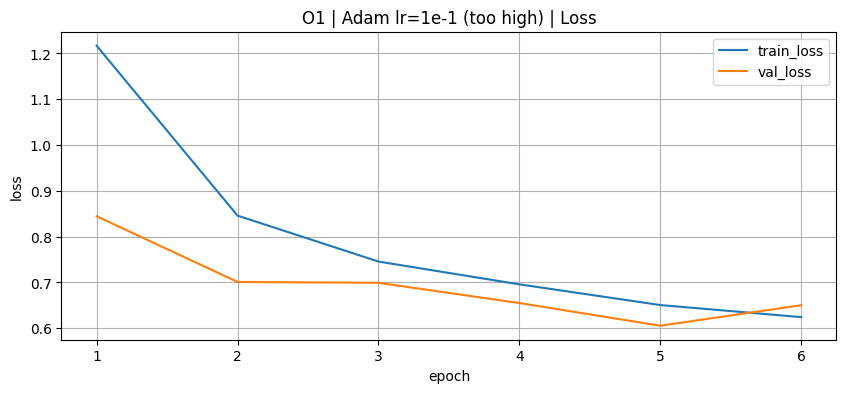

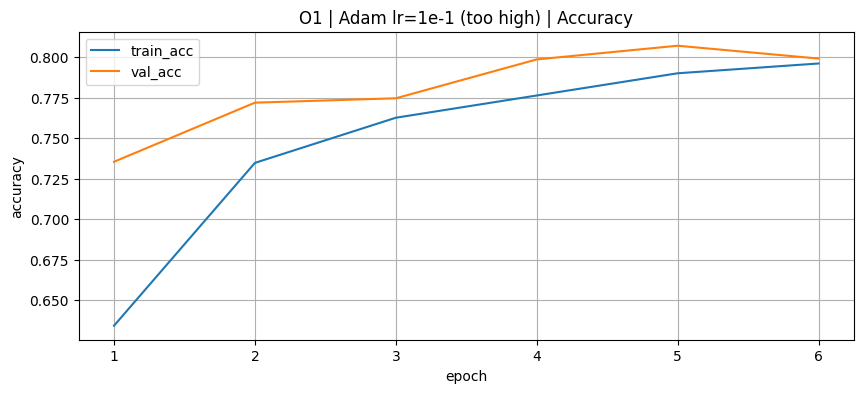

In [16]:
# O1 (LR слишком большой): Adam, lr=1e-1, 5–8 эпох
res_O1 = run_experiment("O1", optimizer_kind="adam", lr=1e-1, epochs=6)
plot_history(res_O1["history"], title="O1 | Adam lr=1e-1 (too high)")


O2: ADAM lr=1e-05, weight_decay=0, momentum=0
Epoch 01/6 | train loss=3.1667, acc=0.3203 | val loss=2.6819, acc=0.5128 | 13.5s
Epoch 02/6 | train loss=2.4354, acc=0.5648 | val loss=2.1776, acc=0.6182 | 14.0s
Epoch 03/6 | train loss=2.0152, acc=0.6382 | val loss=1.8209, acc=0.6690 | 13.7s
Epoch 04/6 | train loss=1.6999, acc=0.6800 | val loss=1.5387, acc=0.7025 | 13.2s
Epoch 05/6 | train loss=1.4579, acc=0.7092 | val loss=1.3294, acc=0.7260 | 17.2s
Epoch 06/6 | train loss=1.2700, acc=0.7325 | val loss=1.1632, acc=0.7465 | 12.4s


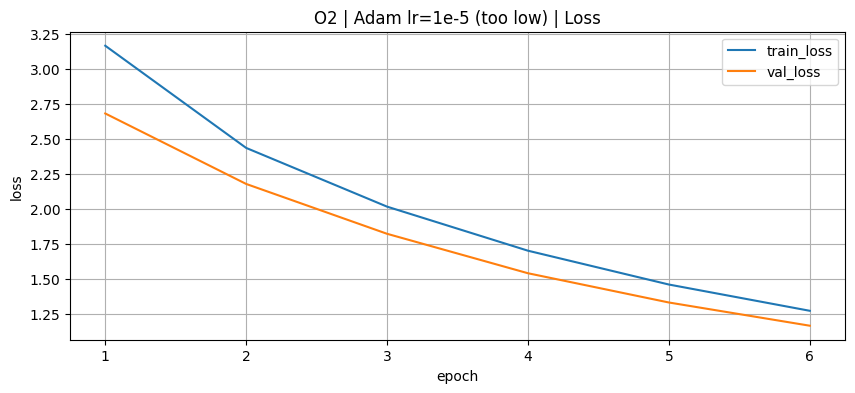

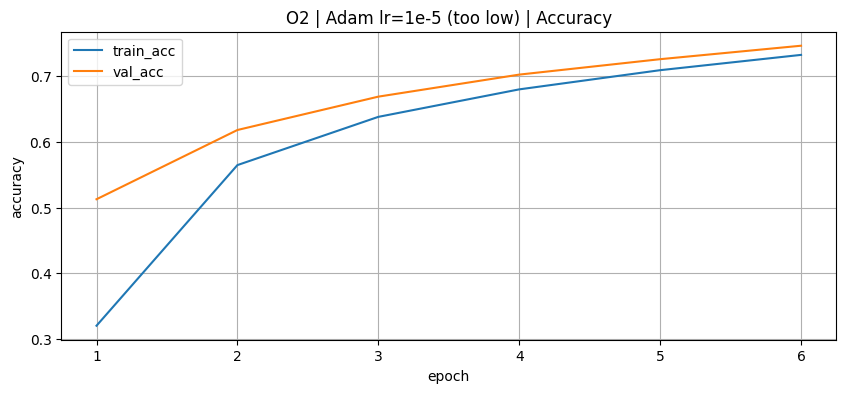

In [17]:
# O2 (LR слишком маленький): Adam, lr=1e-5, 5–8 эпох
res_O2 = run_experiment("O2", optimizer_kind="adam", lr=1e-5, epochs=6)
plot_history(res_O2["history"], title="O2 | Adam lr=1e-5 (too low)")


O3: SGD lr=0.01, weight_decay=0.0001, momentum=0.9
Epoch 01/12 | train loss=0.8934, acc=0.7381 | val loss=0.5682, acc=0.8129 | 12.4s
Epoch 02/12 | train loss=0.5208, acc=0.8234 | val loss=0.4982, acc=0.8320 | 12.4s
Epoch 03/12 | train loss=0.4460, acc=0.8440 | val loss=0.4603, acc=0.8438 | 12.1s
Epoch 04/12 | train loss=0.3969, acc=0.8580 | val loss=0.4433, acc=0.8486 | 21.8s
Epoch 05/12 | train loss=0.3630, acc=0.8688 | val loss=0.4469, acc=0.8496 | 13.6s
Epoch 06/12 | train loss=0.3396, acc=0.8750 | val loss=0.4459, acc=0.8468 | 12.6s
Epoch 07/12 | train loss=0.3164, acc=0.8824 | val loss=0.4291, acc=0.8517 | 13.2s
Epoch 08/12 | train loss=0.2956, acc=0.8871 | val loss=0.4418, acc=0.8499 | 12.5s
Epoch 09/12 | train loss=0.2817, acc=0.8916 | val loss=0.4274, acc=0.8580 | 12.3s
Epoch 10/12 | train loss=0.2670, acc=0.8961 | val loss=0.4394, acc=0.8542 | 12.2s
Epoch 11/12 | train loss=0.2539, acc=0.9002 | val loss=0.4445, acc=0.8536 | 20.8s
Epoch 12/12 | train loss=0.2463, acc=0.9028 | 

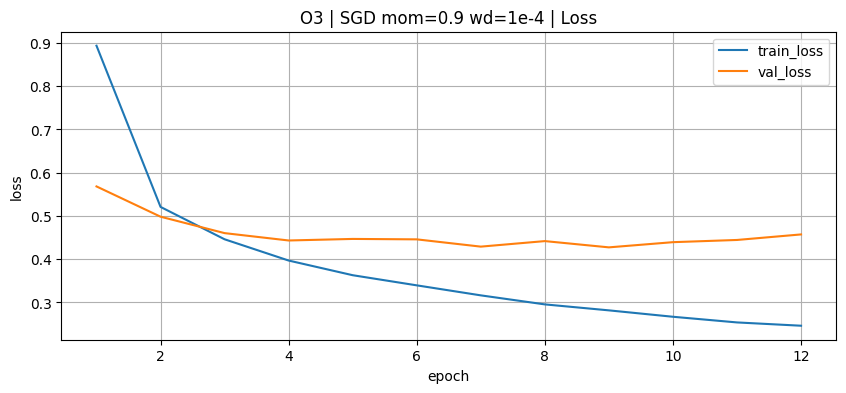

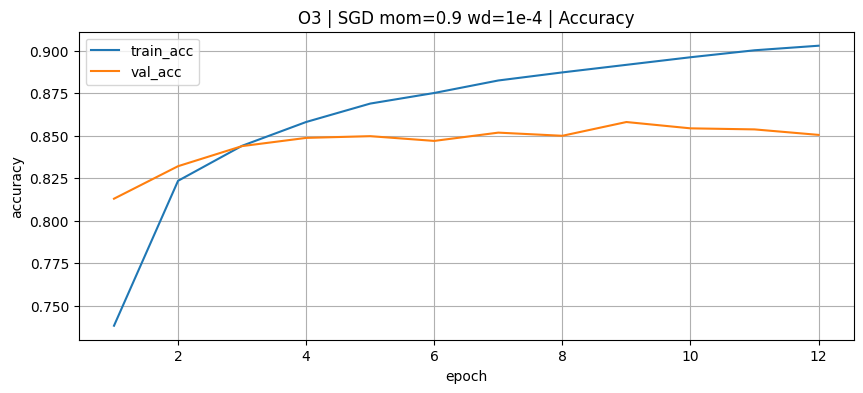

In [18]:
# O3 (SGD+momentum + weight decay): lr разумный (1e-2..1e-3), momentum=0.9, weight_decay>0
# Начнём с lr=1e-2; если будет плохо — поменяй на 1e-3.
res_O3 = run_experiment("O3", optimizer_kind="sgd", lr=1e-2, epochs=12, momentum=0.9, weight_decay=1e-4)
plot_history(res_O3["history"], title="O3 | SGD mom=0.9 wd=1e-4")

In [19]:
results_O = [res_O1, res_O2, res_O3]
print("\nSummary (best val acc):")
for r in results_O:
    print(r["experiment_id"], "best_val_acc=", round(r["best_val_accuracy"], 4), "epochs=", r["epochs_trained"])


Summary (best val acc):
O1 best_val_acc= 0.807 epochs= 6
O2 best_val_acc= 0.7465 epochs= 6
O3 best_val_acc= 0.858 epochs= 12


## 4. Артефакты (обязательно)

В папке `homeworks/HW08-09/artifacts/` должны быть:

1) `runs.csv` – таблица результатов по всем экспериментам E1-E4 и O1-O3 (по одной строке на эксперимент).

    Минимальные поля (рекомендуется именно так):

    - `experiment_id` (E1/E2/E3/E4/O1/O2/O3)
    - `dataset` (KMNIST/EMNIST/CIFAR10)
    - `seed`
    - `model_summary` (коротко: hidden sizes / activation / dropout / batchnorm)
    - `optimizer` (Adam/SGD)
    - `lr`
    - `momentum` (пусто или 0 для Adam)
    - `weight_decay` (0 если не используется)
    - `epochs_trained`
    - `best_val_accuracy`
    - `best_val_loss`

2) `best_model.pt` – сохранённый `state_dict()` лучшей модели (E4).  
3) `best_config.json` – конфиг лучшей модели (архитектура, ключевые гиперпараметры обучения, seed, датасет).  
4) `figures/curves_best.png` – график train/val loss (или loss+accuracy) для лучшего прогона (E4).  
5) `figures/curves_lr_extremes.png` – график(и), показывающий(ие) поведение O1 и O2 (LR слишком большой/маленький).  
   - можно одним рисунком на одной оси или двумя подграфиками; главное – чтобы было видно различие.

---

In [26]:
# Пути
ART_DIR = os.path.join("artifacts")
FIG_DIR = os.path.join(ART_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

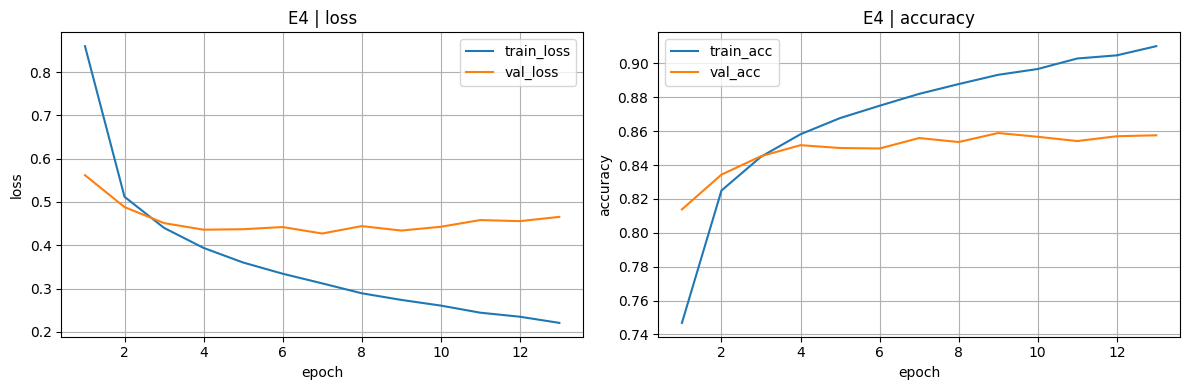

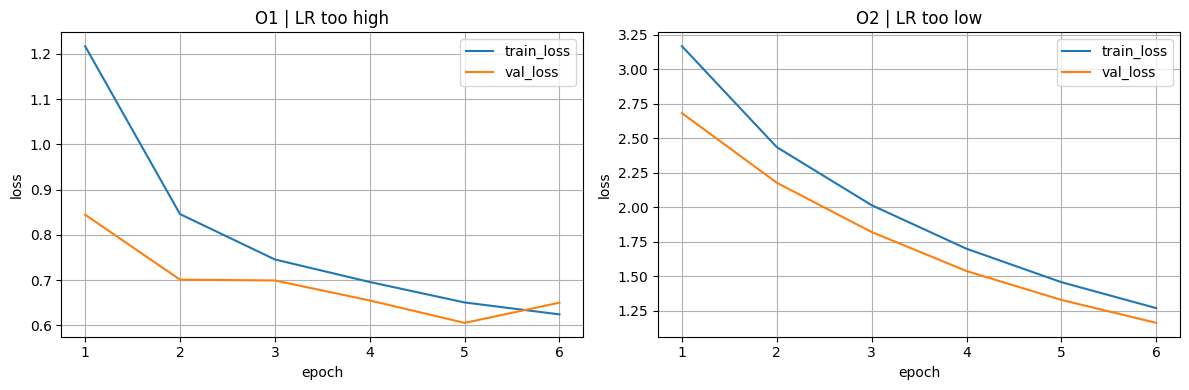

Saved artifacts to: artifacts
Saved runs.csv with rows: 7


In [29]:
# 1) best_model.pt (E4)
torch.save(model_E4.state_dict(), os.path.join(ART_DIR, "best_model.pt"))


# 2) best_config.json (E4)
dataset = "EMNIST"

dropout_E4 = float(p_dropout) if best_kind == "dropout" else 0.0
use_batchnorm_E4 = bool(best_kind == "bn")

best_val_accuracy_E4 = float(np.max(history_E4["val_acc"]))
best_val_loss_E4     = float(np.min(history_E4["val_loss"]))
epochs_trained_E4    = int(len(history_E4["val_acc"]))

best_config = {
    "experiment_id": "E4",
    "dataset": dataset,
    "seed": int(SEED),

    # данные / модель
    "input_shape": [1, 28, 28],          
    "num_classes": int(num_classes),    
    "hidden_sizes": list(hidden_sizes_big),
    "activation": "ReLU",
    "dropout": dropout_E4,
    "use_batchnorm": use_batchnorm_E4,

    # обучение
    "loss": "CrossEntropyLoss",
    "optimizer_name": "Adam",
    "lr": float(lr),
    "weight_decay": 0.0,
    "momentum": 0.0,
    "batch_size": int(BATCH_SIZE),
    "epochs_max": int(max_epochs_E4),
    "early_stopping_patience": int(patience),

    # итоговые метрики
    "epochs_trained": epochs_trained_E4,
    "best_val_accuracy": best_val_accuracy_E4,
    "best_val_loss": best_val_loss_E4,
    "test_accuracy": float(test_acc),
}

with open(os.path.join(ART_DIR, "best_config.json"), "w", encoding="utf-8") as f:
    json.dump(best_config, f, ensure_ascii=False, indent=2)

# 3) figures/curves_best.png (E4) — loss + accuracy
ep = np.arange(1, len(history_E4["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(ep, history_E4["train_loss"], label="train_loss")
axes[0].plot(ep, history_E4["val_loss"], label="val_loss")
axes[0].set_title("E4 | loss")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
axes[0].grid(True); axes[0].legend()

axes[1].plot(ep, history_E4["train_acc"], label="train_acc")
axes[1].plot(ep, history_E4["val_acc"], label="val_acc")
axes[1].set_title("E4 | accuracy")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy")
axes[1].grid(True); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "curves_best.png"), dpi=150)
plt.show()

# 4) figures/curves_lr_extremes.png (O1 vs O2) — два подграфика (loss)
hist_O1 = res_O1["history"]
hist_O2 = res_O2["history"]

ep1 = np.arange(1, len(hist_O1["train_loss"]) + 1)
ep2 = np.arange(1, len(hist_O2["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(ep1, hist_O1["train_loss"], label="train_loss")
axes[0].plot(ep1, hist_O1["val_loss"], label="val_loss")
axes[0].set_title("O1 | LR too high")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
axes[0].grid(True); axes[0].legend()

axes[1].plot(ep2, hist_O2["train_loss"], label="train_loss")
axes[1].plot(ep2, hist_O2["val_loss"], label="val_loss")
axes[1].set_title("O2 | LR too low")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("loss")
axes[1].grid(True); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "curves_lr_extremes.png"), dpi=150)
plt.show()

# 5) runs.csv — E1–E4 + O1–O3
def best_metrics(hist):
    best_acc = float(np.max(hist["val_acc"]))
    best_loss = float(np.min(hist["val_loss"]))
    epochs = int(len(hist["val_acc"]))
    return best_acc, best_loss, epochs

def model_summary(hidden_sizes, dropout, batchnorm):
    return f"hidden={list(hidden_sizes)} | act=ReLU | dropout={dropout} | batchnorm={batchnorm}"

rows = []

# E1
acc, loss, epochs = best_metrics(history_E1)
rows.append({
    "experiment_id": "E1",
    "dataset": dataset,
    "seed": int(SEED),
    "model_summary": model_summary(hidden_sizes_big, 0.0, False),
    "optimizer": "Adam",
    "lr": float(lr),
    "momentum": 0,
    "weight_decay": 0,
    "epochs_trained": epochs,
    "best_val_accuracy": acc,
    "best_val_loss": loss,
})

# E2
acc, loss, epochs = best_metrics(history_E2)
rows.append({
    "experiment_id": "E2",
    "dataset": dataset,
    "seed": int(SEED),
    "model_summary": model_summary(hidden_sizes_big, float(p_dropout), False),
    "optimizer": "Adam",
    "lr": float(lr),
    "momentum": 0,
    "weight_decay": 0,
    "epochs_trained": epochs,
    "best_val_accuracy": acc,
    "best_val_loss": loss,
})

# E3
acc, loss, epochs = best_metrics(history_E3)
rows.append({
    "experiment_id": "E3",
    "dataset": dataset,
    "seed": int(SEED),
    "model_summary": model_summary(hidden_sizes_big, 0.0, True),
    "optimizer": "Adam",
    "lr": float(lr),
    "momentum": 0,
    "weight_decay": 0,
    "epochs_trained": epochs,
    "best_val_accuracy": acc,
    "best_val_loss": loss,
})

# E4
rows.append({
    "experiment_id": "E4",
    "dataset": dataset,
    "seed": int(SEED),
    "model_summary": model_summary(hidden_sizes_big, dropout_E4, batchnorm_E4),
    "optimizer": "Adam",
    "lr": float(lr),
    "momentum": 0,
    "weight_decay": 0,
    "epochs_trained": epochs_trained_E4,
    "best_val_accuracy": best_val_accuracy_E4,
    "best_val_loss": best_val_loss_E4,
})

# O1–O3 (архитектура фиксирована как E4)
fixed_summary = model_summary(hidden_sizes_big, dropout_E4, batchnorm_E4)

for r in [res_O1, res_O2, res_O3]:
    rows.append({
        "experiment_id": r["experiment_id"],
        "dataset": dataset,
        "seed": int(SEED),
        "model_summary": fixed_summary,
        "optimizer": "SGD" if r["optimizer"].lower() == "sgd" else "Adam",
        "lr": float(r["lr"]),
        "momentum": float(r["momentum"]),
        "weight_decay": float(r["weight_decay"]),
        "epochs_trained": int(r["epochs_trained"]),
        "best_val_accuracy": float(r["best_val_accuracy"]),
        "best_val_loss": float(r["best_val_loss"]),
    })

csv_path = os.path.join(ART_DIR, "runs.csv")
fieldnames = [
    "experiment_id", "dataset", "seed", "model_summary",
    "optimizer", "lr", "momentum", "weight_decay",
    "epochs_trained", "best_val_accuracy", "best_val_loss"
]

with open(csv_path, "w", newline="", encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=fieldnames)
    w.writeheader()
    w.writerows(rows)

print("Saved artifacts to:", ART_DIR)
print("Saved runs.csv with rows:", len(rows))